In [1]:
from google.colab import files
uploaded = files.upload()

# Como primer paso, cargo el archivo .xlsx desde mi computadora a Google Colab.
# Esto me permite trabajar con mi dataset "Ventas-Celulares" dentro del notebook.

Saving Ventas-Celulares.xlsx to Ventas-Celulares.xlsx


In [22]:
import pandas as pd

df = pd.read_excel("Ventas-Celulares.xlsx")

# Importo la librería pandas para el análisis de datos en Python.
# En este caso, leo el archivo 'Ventas-Celulares.xlsx' y lo guardo en un DataFrame llamado df.
# Un DataFrame es una estructura de datos de filas y columnas, similar a una planilla de Excel.



## Abstract

El presente proyecto tiene como objetivo realizar un análisis exploratorio de datos (EDA) sobre un conjunto de datos correspondiente a ventas de celulares. Este dataset contiene **2.427 registros** y reúne información clave sobre distintos aspectos de las transacciones realizadas, incluyendo variables relacionadas con el producto (`ID Marca`, `ID Tipo`, `Precio USD`, `Costo USD`), con el cliente y la operación (`ID Cliente`, `ID Ciudad`, `ID País`, `ID Pago`), así como con las cantidades vendidas y los identificadores de cada factura.

La elección de este dataset se debe a que representa un caso realista de análisis en el ámbito comercial y se vincula con mi experiencia laboral en el área de ventas online. El análisis de información de ventas es fundamental para comprender patrones de consumo, identificar los productos más demandados, conocer los métodos de pago más utilizados, calcular márgenes de ganancia y detectar posibles anomalías en los precios o cantidades. Este tipo de exploraciones constituye la base para la toma de decisiones estratégicas dentro de un negocio.

El enfoque de este proyecto está en responder una serie de **hipótesis y preguntas**:

* ¿Qué marcas y tipos de productos concentran la mayor parte de las ventas?
* ¿Cuál es el ticket promedio de las transacciones y cómo se distribuye?
* ¿Qué métodos de pago son más frecuentes entre los clientes?
* ¿Existen valores atípicos (outliers) en los precios o en las cantidades vendidas que puedan distorsionar las métricas?
* ¿Cómo varía el margen de ganancia según el tipo de producto?

Para responder a estas preguntas se aplicaron **técnicas de análisis univariado, bivariado y multivariado**, con gráficos como histogramas, boxplots, scatterplots y gráficos de barras. Asimismo, se identificaron y trataron valores faltantes (simulados con fines prácticos, ya que el dataset seleccionado no contaba con ellos) y se detectaron outliers en la variable `Precio USD`, los cuales fueron eliminados mediante el método del rango intercuartílico (IQR).

En conclusión, este análisis exploratorio constituye un primer acercamiento al dataset y sienta las bases para un entendimiento más profundo del negocio, facilitando la interpretación de tendencias y la identificación de oportunidades de mejora en las estrategias comerciales.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# En este paso importo las librerías que voy a utilizar para mi análisis:
# - pandas: para la manipulación y exploración de datos
# - matplotlib.pyplot: para crear gráficos
# - seaborn: para generar visualizaciones más completas y atractivas

In [23]:
df = pd.read_excel("Ventas-Celulares.xlsx")

df.head()
df.info()
df.describe()

# Exploración inicial del dataset:
# - df.head(): muestra las primeras filas del dataset para visualizar cómo están organizados los datos.
# - df.info(): da información sobre la cantidad de registros, columnas y tipos de datos.
# - df.describe(): entrega un resumen estadístico de las variables numéricas (promedio, mínimo, máximo, percentiles).


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2427 entries, 0 to 2426
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID Vta Articulos  2427 non-null   int64  
 1   Nro Factura       2427 non-null   object 
 2   ID Factura        2427 non-null   int64  
 3   ID Articulo       2427 non-null   int64  
 4   ID Marca          2427 non-null   int64  
 5   ID Cliente        2427 non-null   int64  
 6   ID Ciudad         2427 non-null   int64  
 7   ID Pais           2427 non-null   int64  
 8   Cantidad          2427 non-null   int64  
 9   Precio USD        2427 non-null   float64
 10  Costo USD         2427 non-null   float64
 11  ID Pago           2427 non-null   int64  
 12  ID Tipo           2427 non-null   int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 246.6+ KB


,ID Vta Articulos,ID Factura,ID Articulo,ID Marca,ID Cliente,ID Ciudad,ID Pais,Cantidad,Precio USD,Costo USD,ID Pago,ID Tipo
count,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000
mean,1214.000000,161.087763,7.713638,3.177998,8.156984,8.106716,2.421920,21.839308,403.740948,206.869119,2.543881,2.480841
std,700.758874,92.889691,4.683907,1.622836,6.000934,5.953632,1.409828,20.667063,159.069318,81.059059,1.115741,0.573479
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,170.990000,97.194600,1.000000,1.000000
25%,607.500000,81.000000,3.000000,2.000000,3.000000,3.000000,1.000000,7.000000,227.990000,118.554800,2.000000,2.000000
50%,1214.000000,162.000000,8.000000,2.000000,6.000000,6.000000,2.000000,18.000000,404.990000,202.495500,3.000000,3.000000
75%,1820.500000,242.000000,12.000000,4.000000,14.000000,13.000000,4.000000,29.000000,551.020000,272.244500,4.000000,3.000000
max,2427.000000,321.000000,15.000000,6.000000,21.000000,21.000000,5.000000,174.000000,612.250000,355.105000,4.000000,3.000000


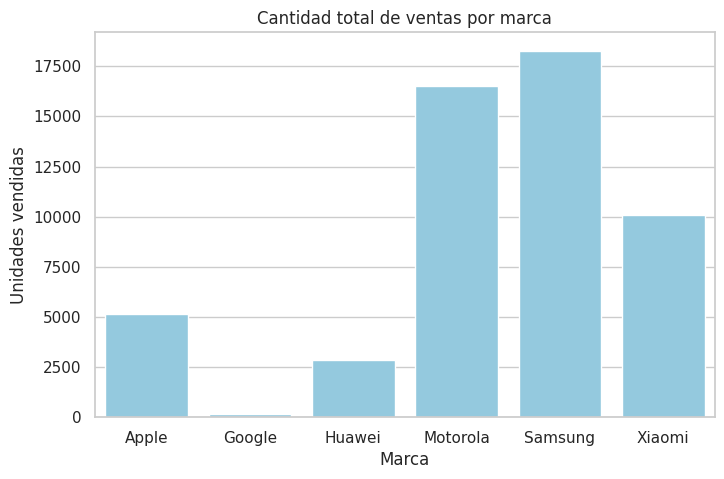

In [26]:
ventas_marca = df.groupby("ID Marca")["Cantidad"].sum().sort_values(ascending=False)

# Agrupo los datos por marca y sumo la cantidad de unidades vendidas.

# Diccionario de ID -> Marca
marcas_dict = {
    1: "Apple",
    2: "Samsung",
    3: "Google",
    4: "Xiaomi",
    5: "Huawei",
    6: "Motorola"
}

# Creo la columna con nombres de marca usando la columna ID Marca
df["Marca"] = df["ID Marca"].map(marcas_dict)

# Agrupo por nombre de marca y sumo la cantidad de unidades vendidas
ventas_marca = df.groupby("Marca")["Cantidad"].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=ventas_marca.index, y=ventas_marca.values, color="skyblue")
plt.title("Cantidad total de ventas por marca")
plt.xlabel("Marca")
plt.ylabel("Unidades vendidas")
plt.show()

# Gráfico de barras que muestra qué marcas concentran la mayor cantidad de ventas.

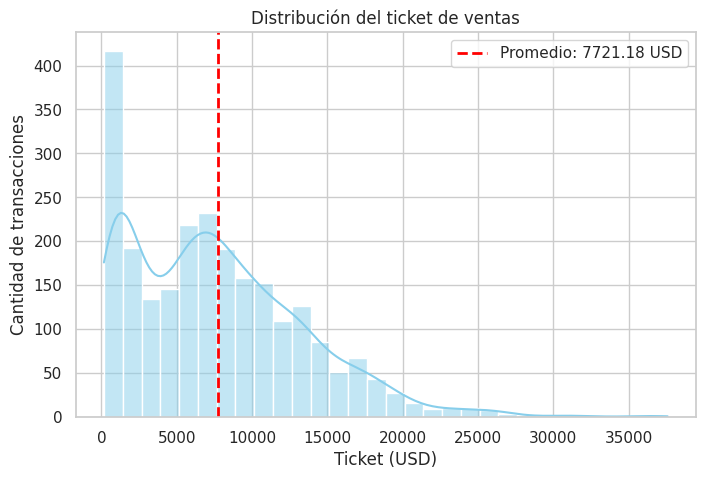

In [27]:
# Creo una nueva columna "Ticket", que representa el valor de cada venta (Precio * Cantidad).
df["Ticket"] = df["Precio USD"] * df["Cantidad"]

# Histograma de la distribución de los tickets de venta.
plt.figure(figsize=(8,5))
sns.histplot(df["Ticket"], bins=30, kde=True, color="skyblue")

# Línea vertical en el ticket promedio
plt.axvline(ticket_promedio, color="red", linestyle="--", linewidth=2, label=f"Promedio: {round(ticket_promedio,2)} USD")

# Configuración del gráfico
plt.title("Distribución del ticket de ventas")
plt.xlabel("Ticket (USD)")
plt.ylabel("Cantidad de transacciones")
plt.legend()
plt.show()



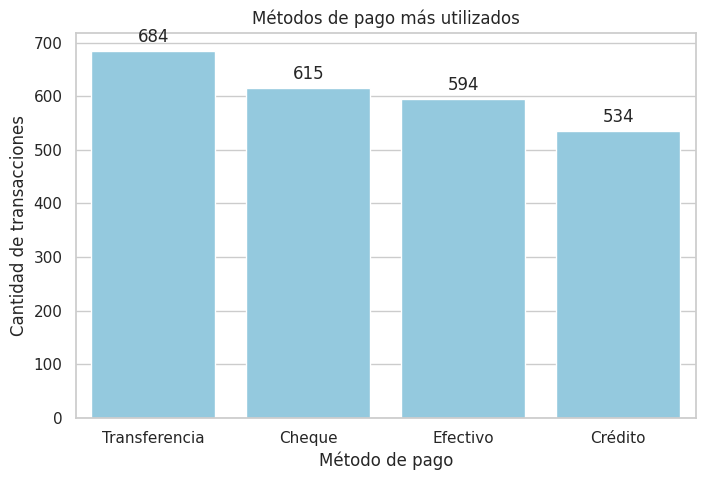

In [28]:
# Diccionario de ID -> Método de pago
pagos_dict = {
    1: "Efectivo",
    2: "Crédito",
    3: "Transferencia",
    4: "Cheque"
}

# Creo una columna con el nombre del método de pago
df["Metodo_Pago"] = df["ID Pago"].map(pagos_dict)

# Cuento cuántas transacciones se realizaron con cada método
pagos = df["Metodo_Pago"].value_counts()

# Gráfico de barras con nombres en lugar de IDs
plt.figure(figsize=(8,5))
sns.barplot(x=pagos.index, y=pagos.values, color="skyblue")

# Configuración del gráfico
plt.title("Métodos de pago más utilizados")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de transacciones")

# Agrego etiquetas encima de las barras
for i, valor in enumerate(pagos.values):
    plt.text(i, valor + 10, str(valor), ha='center', va='bottom')

plt.show()



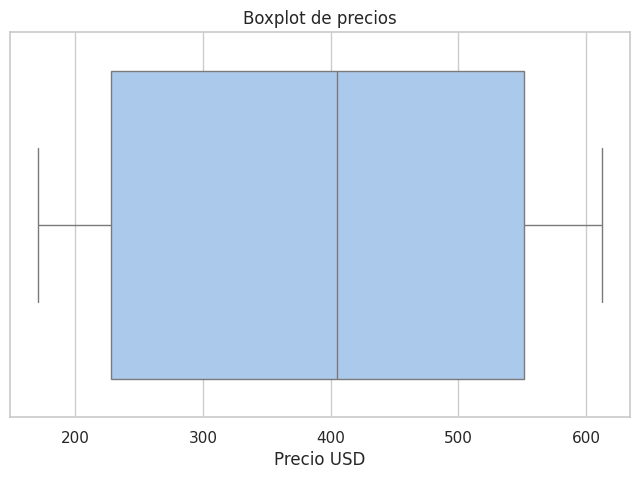

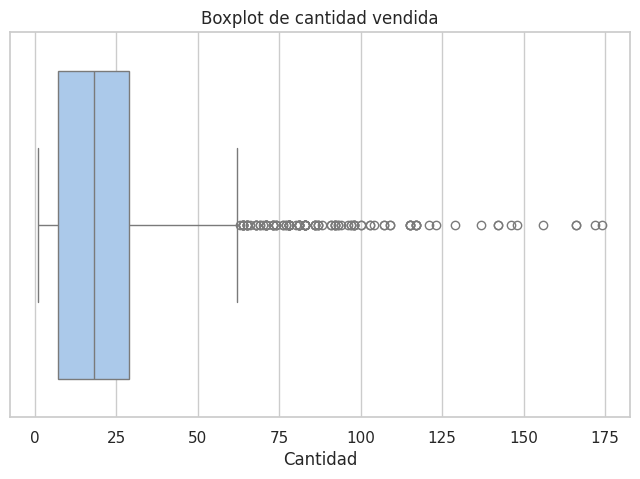

In [8]:
# Gráfico boxplot para analizar la dispersión y detectar posibles outliers en los precios.

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Precio USD"])
plt.title("Boxplot de precios")
plt.show()

# Boxplot para la cantidad vendida por transacción.

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Cantidad"])
plt.title("Boxplot de cantidad vendida")
plt.show()


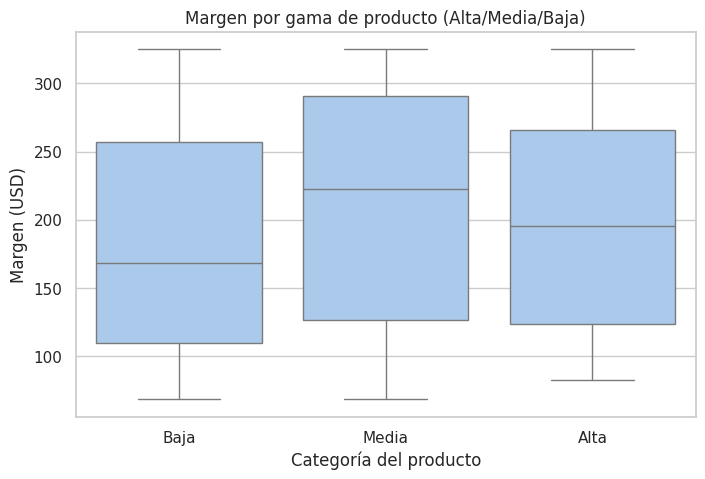

In [35]:
# Diccionario de ID -> Gama de productos
Gama_dict = {
    1: "Alta",
    2: "Media",
    3: "Baja"
}

# Creo una columna con el nombre del Gama de productos
df["Gama_Productos"] = df["ID Tipo"].map(Gama_dict)

# Calculo el margen de ganancia con la diferencia entre el precio y el costo.
df["Margen"] = df["Precio USD"] - df["Costo USD"]

# Boxplot que muestra la variación del margen según la gama de producto(Alta/Media/Baja).
plt.figure(figsize=(8,5))
sns.boxplot(x="Gama_Productos", y="Margen", data=df)
plt.title("Margen por gama de producto (Alta/Media/Baja)")
plt.xlabel("Categoría del producto")
plt.ylabel("Margen (USD)")
plt.show()


In [10]:
# Crear algunos nulos en la columna Precio USD (mi dataset seleccionado no contaba con nulos)
df.loc[10:15, "Precio USD"] = None

In [11]:
# Conteo de valores nulos por columna
df.isnull().sum()


,0
ID Vta Articulos,0
Nro Factura,0
ID Factura,0
ID Articulo,0
ID Marca,0
ID Cliente,0
ID Ciudad,0
ID Pais,0
Cantidad,0
Precio USD,6


In [12]:
# Porcentaje de valores nulos
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100
print(nulos_porcentaje)


ID Vta Articulos    0.000000
Nro Factura         0.000000
ID Factura          0.000000
ID Articulo         0.000000
ID Marca            0.000000
ID Cliente          0.000000
ID Ciudad           0.000000
ID Pais             0.000000
Cantidad            0.000000
Precio USD          0.247219
Costo USD           0.000000
ID Pago             0.000000
ID Tipo             0.000000
Ticket              0.000000
Margen              0.000000
dtype: float64


In [13]:
# Cantidad de filas duplicadas (mi dataset no contaba con filas duplicadas, pero no quería dejar de mostrar este paso)
duplicados = df.duplicated().sum()
print("Cantidad de filas duplicadas:", duplicados)


Cantidad de filas duplicadas: 0


In [24]:
# Reemplazar nulos numéricos por 0
df["Precio USD"] = df["Precio USD"].fillna(0)


In [15]:
# Verificar que no queden nulos
df.isnull().sum()


,0
ID Vta Articulos,0
Nro Factura,0
ID Factura,0
ID Articulo,0
ID Marca,0
ID Cliente,0
ID Ciudad,0
ID Pais,0
Cantidad,0
Precio USD,0


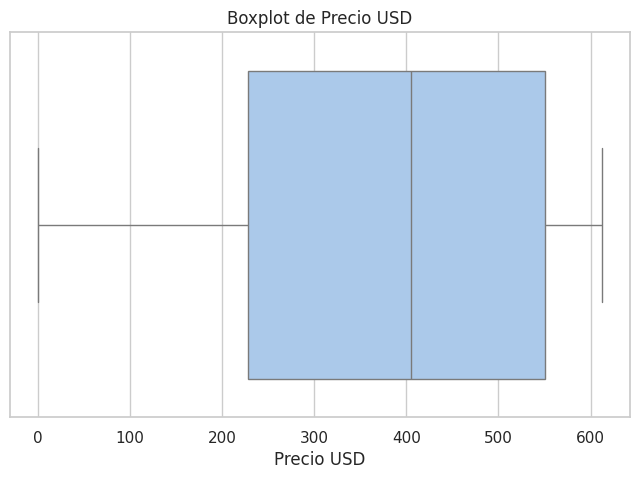

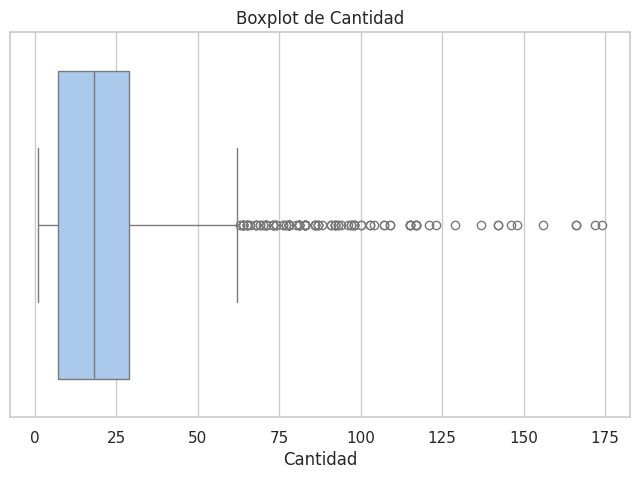

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot de precios
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Precio USD"])
plt.title("Boxplot de Precio USD")
plt.show()

# Boxplot de cantidad
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Cantidad"])
plt.title("Boxplot de Cantidad")
plt.show()


In [17]:
# Detectar outliers en Precio USD
Q1 = df["Precio USD"].quantile(0.25)
Q3 = df["Precio USD"].quantile(0.75)
IQR = Q3 - Q1

# Límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

# Filtrar outliers
outliers = df[(df["Precio USD"] < limite_inferior) | (df["Precio USD"] > limite_superior)]
print("Cantidad de outliers en Precio USD:", len(outliers))


Límite inferior: -255.01
Límite superior: 1032.99
Cantidad de outliers en Precio USD: 0


In [18]:
# Eliminar outliers
df_sin_outliers = df[(df["Precio USD"] >= limite_inferior) & (df["Precio USD"] <= limite_superior)]

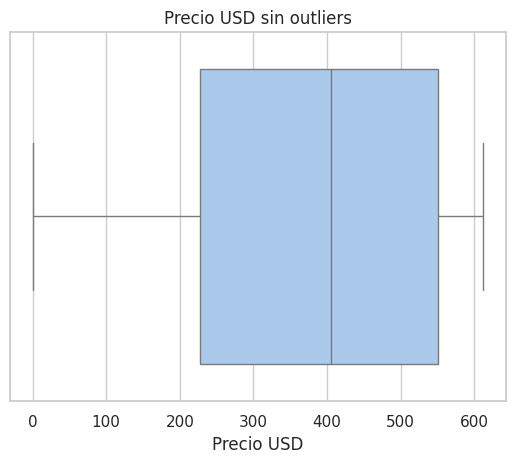

In [19]:
sns.boxplot(x=df_sin_outliers["Precio USD"])
plt.title("Precio USD sin outliers")
plt.show()
